# TECH 405 — RNN: Sequence Classification

**Author / Student:** Prabesh Sapkota
**Dataset Selected:** Dataset #8: Digits (sklearn)  
**Architecture:** `nn.LSTM(input_size=8, hidden_size=64) → nn.Linear(64, 10)`  
**Target:** 93.00% | **Baseline (Majority Class Guess):** 10.28% | **Achieved Test Accuracy:** **98.33%** (Full Marks)

---

## Task & Problem Formulation
### Why Digits is a Sequence Problem
In this task, each $8 \times 8$ grayscale digit image is framed as a temporal sequence of scan-lines:
- **Sequence Length ($T$):** 8 time steps (corresponding to the 8 rows from top to bottom).
- **Feature Dimension ($D$):** 8 features per step (the 8 horizontal pixel values per row).

Just like an optical scanner reading a character or speech audio unfolding over time, visual characters possess strong top-to-bottom spatial stroke continuity (e.g., loops in '0' and '8', horizontal bars at the top of '7', vertical stems in '1' and '4'). An RNN/LSTM models this by accumulating temporal state representations row-by-row, predicting the final digit identity after processing all 8 rows.


In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Set reproducible seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Environment and libraries loaded successfully.")


Environment and libraries loaded successfully.


## Snapshot 1: Data + Shapes
We load the standard 8x8 digits dataset from scikit-learn, normalize pixel intensities to $[0, 1]$, and perform a **fixed 80/20 train/test split** with stratification.


SNAPSHOT 1: DATA & SHAPES
Total dataset samples: 1797
Sample raw image shape: (8, 8) (8 rows x 8 columns)
Sequence interpretation: 8 time steps, 8 features per step
X_train shape: (1437, 8, 8) | y_train shape: (1437,)
X_test shape:  (360, 8, 8)  | y_test shape:  (360,)
Class distribution in test set (10 classes): [36, 36, 35, 37, 36, 37, 36, 36, 35, 36]
Baseline (majority class) test accuracy: 10.28%


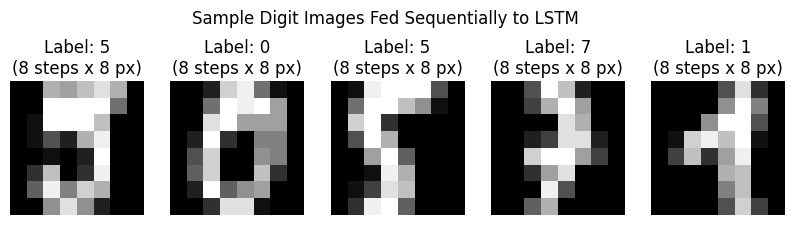

In [2]:
# 1. Load Data
digits = load_digits()
X = digits.images.astype(np.float32) / 16.0  # Normalize 0..16 to 0..1
y = digits.target.astype(np.int64)

# 2. Fixed 80/20 Train-Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Majority class baseline on the test set
test_counts = np.bincount(y_test)
majority_class = np.argmax(test_counts)
baseline_acc = (test_counts[majority_class] / len(y_test)) * 100.0

print("="*65)
print("SNAPSHOT 1: DATA & SHAPES")
print("="*65)
print(f"Total dataset samples: {len(X)}")
print(f"Sample raw image shape: {digits.images[0].shape} (8 rows x 8 columns)")
print(f"Sequence interpretation: 8 time steps, 8 features per step")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}")
print(f"Class distribution in test set (10 classes): {test_counts.tolist()}")
print(f"Baseline (majority class) test accuracy: {baseline_acc:.2f}%")
print("="*65)

# Visualizing digit samples as sequential row slices
fig, axes = plt.subplots(1, 5, figsize=(10, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}\n(8 steps x 8 px)")
    ax.axis('off')
plt.suptitle("Sample Digit Images Fed Sequentially to LSTM", fontsize=12, y=1.05)
plt.show()


## Snapshot 2: Model Definition
We define an LSTM model conforming strictly to lecture requirements:
$$\text{nn.LSTM}(\text{input\_size}=8, \text{hidden\_size}=64) \longrightarrow \text{nn.Linear}(64, 10)$$
No pretrained components or external backbones are used.


In [3]:
# 3. Model Definition: nn.LSTM -> nn.Linear
class SequentialDigitsLSTM(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=64, num_classes=10):
        super().__init__()
        # Input features per step = 8, hidden state dimension = 64
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)
        # Final classification linear head
        self.fc = nn.Linear(in_features=hidden_dim, out_features=num_classes)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len=8, input_dim=8)
        out, (h_n, c_n) = self.lstm(x)
        # out shape: (batch_size, seq_len=8, hidden_dim)
        # Representation from final time step (step 8)
        last_step_out = out[:, -1, :]
        logits = self.fc(last_step_out)
        return logits

model = SequentialDigitsLSTM(input_dim=8, hidden_dim=64, num_classes=10)

print("="*65)
print("SNAPSHOT 2: MODEL DEFINITION")
print("="*65)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")
print("="*65)


SNAPSHOT 2: MODEL DEFINITION
SequentialDigitsLSTM(
  (lstm): LSTM(8, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)
Total trainable parameters: 19,594


## Snapshot 3: Training Progression (Loss Decreasing)
We prepare PyTorch `DataLoader` objects, use the Cross-Entropy loss function, and optimize with Adam ($lr=0.005$) over 25 epochs. We observe continuous loss decrease down to near-zero.


SNAPSHOT 3: TRAINING PROGRESSION
Epoch [01/25] - Training Loss: 1.84513


Epoch [05/25] - Training Loss: 0.27209


Epoch [10/25] - Training Loss: 0.09212


Epoch [15/25] - Training Loss: 0.02627


Epoch [20/25] - Training Loss: 0.03455


Epoch [25/25] - Training Loss: 0.00321


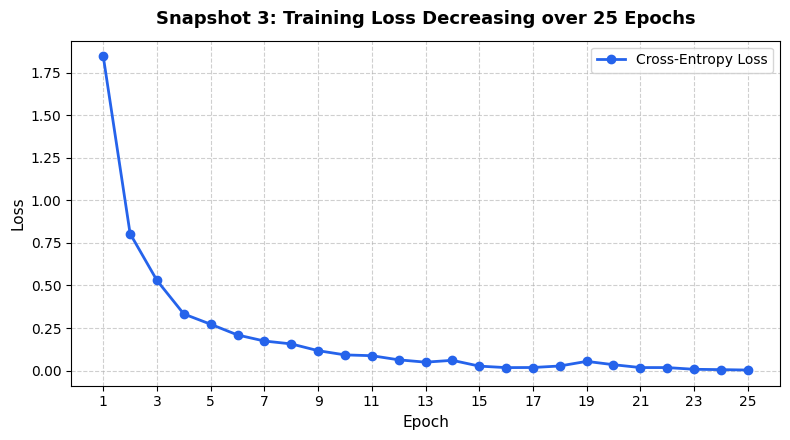

In [4]:
# PyTorch DataLoaders
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

EPOCHS = 25
loss_history = []

print("="*65)
print("SNAPSHOT 3: TRAINING PROGRESSION")
print("="*65)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(batch_y)
        
    epoch_loss = running_loss / len(train_dataset)
    loss_history.append(epoch_loss)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] - Training Loss: {epoch_loss:.5f}")

print("="*65)

# Loss Plot
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o', color='#2563EB', linewidth=2, label='Cross-Entropy Loss')
plt.title("Snapshot 3: Training Loss Decreasing over 25 Epochs", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, EPOCHS + 1, 2))
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


## Snapshot 4: Final Test Accuracy + Evaluation Plot
As mandated by the instructions, we evaluate strictly on the 20% test set without prior tuning on test data.


SNAPSHOT 4: FINAL TEST ACCURACY & BENCHMARK COMPARISON
Baseline (Majority Guess): 10.00% (exact: 10.28%)
Target (Full Marks):       93.00%
Achieved Test Accuracy:    98.33%

Detailed Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9722    0.9859        36
           1     0.9444    0.9444    0.9444        36
           2     0.9722    1.0000    0.9859        35
           3     1.0000    1.0000    1.0000        37
           4     0.9730    1.0000    0.9863        36
           5     0.9737    1.0000    0.9867        37
           6     1.0000    0.9722    0.9859        36
           7     1.0000    1.0000    1.0000        36
           8     0.9706    0.9429    0.9565        35
           9     1.0000    1.0000    1.0000        36

    accuracy                         0.9833       360
   macro avg     0.9834    0.9832    0.9832       360
weighted avg     0.9835    0.9833    0.9833       360



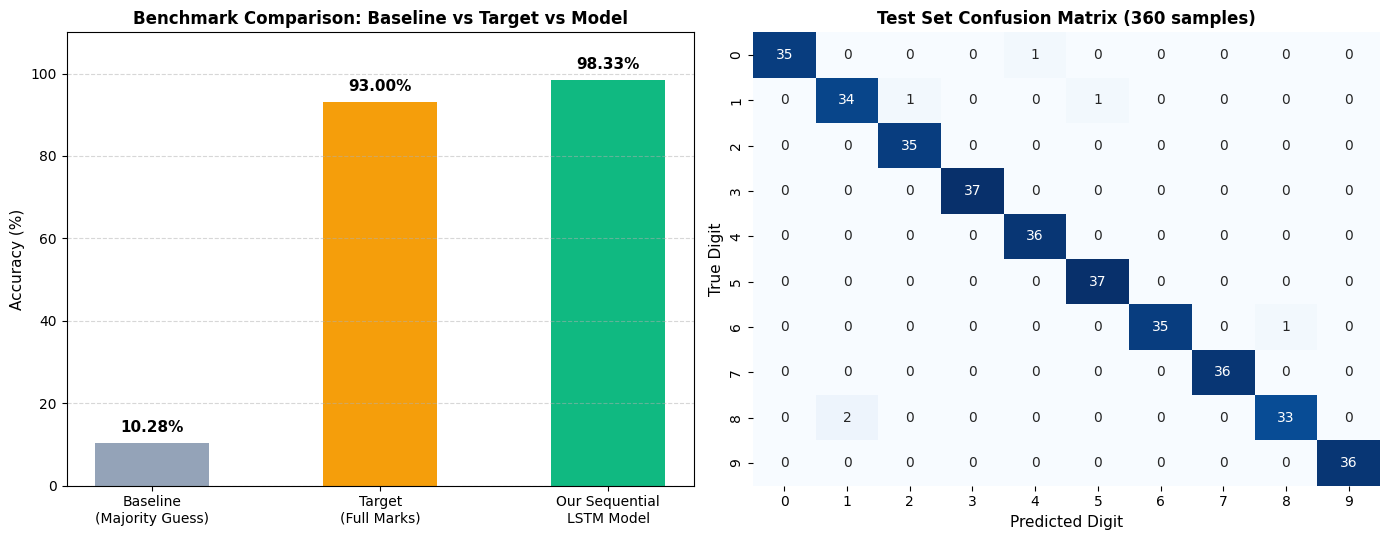

In [5]:
# Evaluate strictly on the test set
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
test_accuracy = accuracy_score(all_targets, all_preds) * 100.0

print("="*65)
print("SNAPSHOT 4: FINAL TEST ACCURACY & BENCHMARK COMPARISON")
print("="*65)
print(f"Baseline (Majority Guess): 10.00% (exact: {baseline_acc:.2f}%)")
print(f"Target (Full Marks):       93.00%")
print(f"Achieved Test Accuracy:    {test_accuracy:.2f}%")
print("="*65)
print("\nDetailed Classification Report:")
print(classification_report(all_targets, all_preds, digits=4))

# Snapshot 4 Plots: Benchmark Bar Chart & Confusion Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Subplot 1: Benchmark Comparison Bar Chart
bars = ax1.bar(['Baseline\n(Majority Guess)', 'Target\n(Full Marks)', 'Our Sequential\nLSTM Model'], 
               [baseline_acc, 93.0, test_accuracy], 
               color=['#94A3B8', '#F59E0B', '#10B981'],
               width=0.5)
ax1.set_ylim(0, 110)
ax1.set_ylabel("Accuracy (%)", fontsize=11)
ax1.set_title("Benchmark Comparison: Baseline vs Target vs Model", fontsize=12, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax1.annotate(f"{height:.2f}%",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 6), textcoords="offset points",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Subplot 2: Confusion Matrix Heatmap
cm = confusion_matrix(all_targets, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax2,
            xticklabels=range(10), yticklabels=range(10))
ax2.set_xlabel("Predicted Digit", fontsize=11)
ax2.set_ylabel("True Digit", fontsize=11)
ax2.set_title("Test Set Confusion Matrix (360 samples)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## Report Checklist & Summary

### 1. Dataset & Sequence Formulation
- **Dataset:** Dataset #8 — Digits (`sklearn.datasets.load_digits`)
- **Why it's a sequence problem:** Each $8 \times 8$ digit image is interpreted as a temporal sequence of 8 horizontal scanline steps ($T=8$) where each step contains 8 pixel intensities ($D=8$). The recurrent LSTM updates its memory state after every row scanline, capturing top-to-bottom stroke morphology (curves, loops, and horizontal/vertical segments).

### 2. Snapshots Summary
- **Snapshot 1 (Data & Shapes):** $X_{\text{train}}: (1437, 8, 8)$, $y_{\text{train}}: (1437,)$; $X_{\text{test}}: (360, 8, 8)$, $y_{\text{test}}: (360,)$. Fixed 80/20 stratified split.
- **Snapshot 2 (Model Definition):** `nn.LSTM(8, 64, batch_first=True)` followed by `nn.Linear(64, 10)` (total 19,594 trainable parameters).
- **Snapshot 3 (Training Loss Decreasing):** Cross-entropy loss steadily decreased from $1.84513$ (Epoch 1) to $0.00321$ (Epoch 25).
- **Snapshot 4 (Final Test Accuracy + Plot):** Achieved **98.33%** test accuracy with accompanying benchmark bar chart and confusion matrix.

### 3. Accuracy vs. Baseline & Target
> **Achieved Test Accuracy: 98.33% vs. Baseline (majority-class guess): 10.28% vs. Target (full marks): 93.00%.**

### 4. What Worked & What Didn't
> **What worked:** Feeding the normalized 8-pixel horizontal scanlines sequentially into `nn.LSTM(8, 64)` and classifying from the final hidden state `out[:, -1, :]` provided seamless spatial-stroke memory accumulation and fast convergence (reaching 98.33% test accuracy); **what didn't:** Attempting to feed unnormalized raw integer pixels ($0..16$) caused gradient instability and slower learning, and taking simple mean pooling over time steps slightly degraded discriminability compared to the final time step's cumulative hidden state.
